阶段1：构造模型

在票价确定的前提下，预测各航段的客流量（已完成）。

阶段2：解析过程

根据客流信息分配舱位，以确定总收益。
客舱分为两类：短途类（AB或BC，称为S类）和长途类（AC，称为L类），总容量为C。

根据是否满座进行分类：

若不满座（S+L≤C），则按S、L和C的预测比例分配舱位，以实现收益最大化。
若满座（S+L>C），则需根据销售量变化预测进行取舍，并作如下判断：
若票价AB+BC>AC，则优先将舱位拆分为AB和BC段销售，S的值取min(AB, BC)，其余舱位分配给L。
若票价AB+BC<AC，则优先分配舱位给AC段，剩余舱位分配给AB和BC段。

阶段3：求总收益最大值

以票价为自变量，总收益为因变量，绘制总收益曲线，并求出总收益的最大值。

## 加载CSV文件

In [1]:
import pandas as pd
import numpy as np

# 读取CSV文件
# /Users/zhanyu/code/data-hh/海航系销售结果数据
df = pd.read_csv('../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221653.csv')

# 显示前两行数据以确保正确加载
print(df.shape)
print(df.head(5))

(978515, 15)
     flt_date                    segment        flt_no bd_type  dep_time  cap  \
0  2023-01-01  gK3uAaRHrOs=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  18:00:00    0   
1  2023-01-01  TtI1YSy7OME=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  20:00:00    0   
2  2023-01-01  gK3uAaRHrOs=-TtI1YSy7OME=  jpD8rZ2KA6Y=      未知  18:00:00    0   
3  2023-01-01  5t+HPO9Mu/w=-X5e5r3CS4OA=  izjfHOxAho4=      窄体  13:25:00  132   
4  2023-01-01  X5e5r3CS4OA=-5t+HPO9Mu/w=  nKALH9OikCM=      窄体  16:15:00  132   

  aircraft  legs  leg_no  duration   tkt_rev  pax             a             b  \
0      NaN     3       3      0.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=   
1      NaN     3       2      3.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=   
2      NaN     3       1      1.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=   
3      319     1       1      1.70  223630.0  127  5t+HPO9Mu/w=  X5e5r3CS4OA=   
4      319     1       1      2.28   76854.0   60  X5e5r3CS4OA=  5t+HPO9Mu/w=   

             

In [2]:
df.info()   #information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 978515 entries, 0 to 978514
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   flt_date  978515 non-null  object 
 1   segment   978515 non-null  object 
 2   flt_no    978515 non-null  object 
 3   bd_type   978515 non-null  object 
 4   dep_time  978515 non-null  object 
 5   cap       978515 non-null  int64  
 6   aircraft  955978 non-null  object 
 7   legs      978515 non-null  int64  
 8   leg_no    978515 non-null  int64  
 9   duration  978515 non-null  float64
 10  tkt_rev   978515 non-null  float64
 11  pax       978515 non-null  int64  
 12  a         978515 non-null  object 
 13  b         978515 non-null  object 
 14  c         390360 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 112.0+ MB


In [3]:
#finding the null values
df.isnull().sum()

flt_date         0
segment          0
flt_no           0
bd_type          0
dep_time         0
cap              0
aircraft     22537
legs             0
leg_no           0
duration         0
tkt_rev          0
pax              0
a                0
b                0
c           588155
dtype: int64

aircraft数据项有2万多空缺项

c数据项有5万8千多空缺项

In [4]:
#describe about the data
# `df.describe()`是Pandas库中的一个方法，用于对DataFrame中的数值列进行描述性统计分析。
df.describe()

,cap,legs,leg_no,duration,tkt_rev,pax
count,978515.000000,978515.000000,978515.000000,978515.000000,9.785150e+05,978515.000000
mean,146.001176,1.798573,1.400716,1.780882,8.459441e+04,100.482606
std,70.949928,0.980593,0.715263,1.004157,7.427669e+04,54.260044
min,0.000000,1.000000,1.000000,0.000000,0.000000e+00,0.000000
25%,138.000000,1.000000,1.000000,1.300000,3.629000e+04,61.000000
50%,164.000000,1.000000,1.000000,1.830000,6.818700e+04,103.000000
75%,178.000000,3.000000,2.000000,2.350000,1.113070e+05,138.000000
max,392.000000,4.000000,6.000000,26.000000,1.545722e+06,391.000000


legs有点问题，应该最高是3，然后leg_no也是，不超过legs
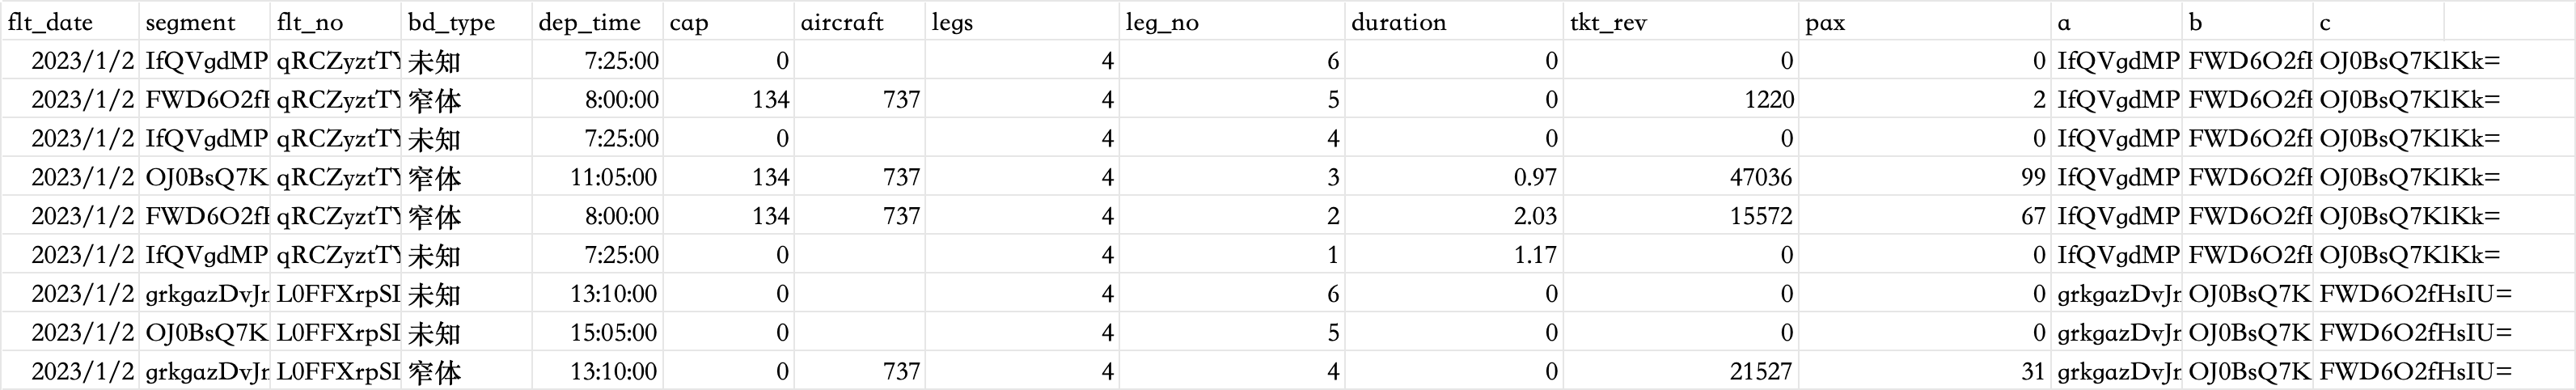

## 清理直飞数据，保留甩飞数据

In [5]:
# 删除 'c' 列中值为空的行
df = df.dropna(subset=['c'])

In [6]:
# 查看删除后的 DataFrame
print(df.head())

      flt_date                    segment        flt_no bd_type  dep_time  \
0   2023-01-01  gK3uAaRHrOs=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  18:00:00   
1   2023-01-01  TtI1YSy7OME=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  20:00:00   
2   2023-01-01  gK3uAaRHrOs=-TtI1YSy7OME=  jpD8rZ2KA6Y=      未知  18:00:00   
15  2023-01-01  tKjndGSl9NQ=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体  08:50:00   
16  2023-01-01  KETr2NAmAHE=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体  12:55:00   

    cap aircraft  legs  leg_no  duration  tkt_rev  pax             a  \
0     0      NaN     3       3      0.00      0.0    0  gK3uAaRHrOs=   
1     0      NaN     3       2      3.00      0.0    0  gK3uAaRHrOs=   
2     0      NaN     3       1      1.00      0.0    0  gK3uAaRHrOs=   
15    0      319     3       3      0.00  11774.0    7  tKjndGSl9NQ=   
16  132      319     3       2      2.68  70520.0   56  tKjndGSl9NQ=   

               b             c  
0   TtI1YSy7OME=  5t+HPO9Mu/w=  
1   TtI1YSy7OME=  5t+HPO9Mu/w=  
2   T

In [7]:
#describe about the data
# `df.describe()`是Pandas库中的一个方法，用于对DataFrame中的数值列进行描述性统计分析。
df.describe()

,cap,legs,leg_no,duration,tkt_rev,pax
count,390360.000000,390360.000000,390360.000000,390360.000000,390360.000000,390360.000000
mean,107.675325,3.001783,2.004475,1.259171,51305.536840,67.060739
std,81.334838,0.042188,0.822174,1.106354,43337.756658,42.378875
min,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,3.000000,1.000000,0.000000,20928.000000,32.000000
50%,158.000000,3.000000,2.000000,1.370000,41810.000000,64.000000
75%,176.000000,3.000000,3.000000,2.000000,69983.250000,99.000000
max,314.000000,4.000000,6.000000,23.580000,775000.000000,281.000000


## 拆分 segment 为 from 和 to

这里暂时不删，等during计算完再删

In [8]:
# 拆分 'segment' 字段为 'from' 和 'to'
df[['from', 'to']] = df['segment'].str.split('-', expand=True)

# 删除原始的 'segment' 字段
# df = df.drop(columns=['segment'])

# 查看结果
print(df.head(10))

      flt_date                    segment        flt_no bd_type  dep_time  \
0   2023-01-01  gK3uAaRHrOs=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  18:00:00   
1   2023-01-01  TtI1YSy7OME=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  20:00:00   
2   2023-01-01  gK3uAaRHrOs=-TtI1YSy7OME=  jpD8rZ2KA6Y=      未知  18:00:00   
15  2023-01-01  tKjndGSl9NQ=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体  08:50:00   
16  2023-01-01  KETr2NAmAHE=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体  12:55:00   
17  2023-01-01  tKjndGSl9NQ=-KETr2NAmAHE=  P6p42wyZFEI=      窄体  08:50:00   
18  2023-01-01  5t+HPO9Mu/w=-tKjndGSl9NQ=  fu7RYrFYvDk=      窄体  16:50:00   
19  2023-01-01  KETr2NAmAHE=-tKjndGSl9NQ=  fu7RYrFYvDk=      窄体  20:20:00   
20  2023-01-01  5t+HPO9Mu/w=-KETr2NAmAHE=  fu7RYrFYvDk=      窄体  16:50:00   
21  2023-01-01  tKjndGSl9NQ=-h9GisD/ZayE=  DVP+qWst7PQ=      窄体  06:15:00   

    cap aircraft  legs  leg_no  duration   tkt_rev  pax             a  \
0     0      NaN     3       3      0.00       0.0    0  gK3uAaRHrOs=   
1     

## 清理legs，leg_no异常行

legs列应该可以直接删除，因为所有的legs都是3，所以没有影响

In [9]:
# 删除 'legs' 列
df = df.drop(columns=['legs'])

In [10]:
df.info()   #information about the data

<class 'pandas.core.frame.DataFrame'>
Index: 390360 entries, 0 to 978445
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   flt_date  390360 non-null  object 
 1   segment   390360 non-null  object 
 2   flt_no    390360 non-null  object 
 3   bd_type   390360 non-null  object 
 4   dep_time  390360 non-null  object 
 5   cap       390360 non-null  int64  
 6   aircraft  380983 non-null  object 
 7   leg_no    390360 non-null  int64  
 8   duration  390360 non-null  float64
 9   tkt_rev   390360 non-null  float64
 10  pax       390360 non-null  int64  
 11  a         390360 non-null  object 
 12  b         390360 non-null  object 
 13  c         390360 non-null  object 
 14  from      390360 non-null  object 
 15  to        390360 non-null  object 
dtypes: float64(2), int64(3), object(11)
memory usage: 50.6+ MB


In [11]:
# 删除 legs 或 leg_no 列中值大于 3 的行
df = df[df['leg_no'] <= 3]

In [12]:
df.describe()

,cap,leg_no,duration,tkt_rev,pax
count,389981.000000,389981.000000,389981.000000,389981.000000,389981.000000
mean,107.748962,2.001413,1.260394,51353.510727,67.123050
std,81.316079,0.816326,1.106194,43331.007998,42.351265
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,20990.000000,32.000000
50%,158.000000,2.000000,1.380000,41855.000000,64.000000
75%,176.000000,3.000000,2.000000,70015.000000,99.000000
max,314.000000,3.000000,23.580000,775000.000000,281.000000


In [13]:
df.info()   #information about the data

<class 'pandas.core.frame.DataFrame'>
Index: 389981 entries, 0 to 978445
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   flt_date  389981 non-null  object 
 1   segment   389981 non-null  object 
 2   flt_no    389981 non-null  object 
 3   bd_type   389981 non-null  object 
 4   dep_time  389981 non-null  object 
 5   cap       389981 non-null  int64  
 6   aircraft  380888 non-null  object 
 7   leg_no    389981 non-null  int64  
 8   duration  389981 non-null  float64
 9   tkt_rev   389981 non-null  float64
 10  pax       389981 non-null  int64  
 11  a         389981 non-null  object 
 12  b         389981 non-null  object 
 13  c         389981 non-null  object 
 14  from      389981 non-null  object 
 15  to        389981 non-null  object 
dtypes: float64(2), int64(3), object(11)
memory usage: 50.6+ MB


检查航段和legs_no是否对得上号

In [14]:
# 定义一个函数来验证 legs_no 是否符合规则
def check_legs_no(row):
    if row['from'] == 'a' and row['to'] == 'b' and row['legs_no'] != 1:
        return False
    elif row['from'] == 'b' and row['to'] == 'c' and row['legs_no'] != 2:
        return False
    elif row['from'] == 'a' and row['to'] == 'c' and row['legs_no'] != 3:
        return False
    return True

# 使用 apply 方法应用检查函数，并获取不符合条件的行
incorrect_rows = df[~df.apply(check_legs_no, axis=1)]

# 显示不符合条件的行
print(incorrect_rows)

Empty DataFrame
Columns: [flt_date, segment, flt_no, bd_type, dep_time, cap, aircraft, leg_no, duration, tkt_rev, pax, a, b, c, from, to]
Index: []


结果显示此时的,legs_no正确

## 拆分 flt_date 为 year, month, day, weekday

In [15]:
# 将 'flt_date' 列转换为 datetime 格式
df['flt_date'] = pd.to_datetime(df['flt_date'])

In [16]:
import chinese_calendar

# 提取年、月、日和星期几
df['year'] = df['flt_date'].dt.year
df['month'] = df['flt_date'].dt.month
df['day'] = df['flt_date'].dt.day
df['weekday'] = df['flt_date'].dt.weekday  # 0 = Monday, 6 = Sunday
# 使用 chinese_calendar.is_holiday 来检查每个日期是否为节假日
df['holiday'] = df['flt_date'].apply(lambda x: chinese_calendar.is_holiday(x))


# 删除原始的 'flt_date' 字段
df = df.drop(columns=['flt_date'])

# 查看结果
print(df.head(5))

                      segment        flt_no bd_type  dep_time  cap aircraft  \
0   gK3uAaRHrOs=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  18:00:00    0      NaN   
1   TtI1YSy7OME=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  20:00:00    0      NaN   
2   gK3uAaRHrOs=-TtI1YSy7OME=  jpD8rZ2KA6Y=      未知  18:00:00    0      NaN   
15  tKjndGSl9NQ=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体  08:50:00    0      319   
16  KETr2NAmAHE=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体  12:55:00  132      319   

    leg_no  duration  tkt_rev  pax             a             b             c  \
0        3      0.00      0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=  5t+HPO9Mu/w=   
1        2      3.00      0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=  5t+HPO9Mu/w=   
2        1      1.00      0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=  5t+HPO9Mu/w=   
15       3      0.00  11774.0    7  tKjndGSl9NQ=  KETr2NAmAHE=  5t+HPO9Mu/w=   
16       2      2.68  70520.0   56  tKjndGSl9NQ=  KETr2NAmAHE=  5t+HPO9Mu/w=   

            from            to  year  month 

## 拆分 dep_time 为 hour, minute, second

In [17]:
# 拆分 'dep_time' 字段
df[['hour', 'minute', 'second']] = df['dep_time'].str.split(':', expand=True)

# 将拆分的结果转换为整数
df['hour'] = df['hour'].astype(int)
df['minute'] = df['minute'].astype(int)
df['second'] = df['second'].astype(int)

# 删除原始的 'dep_time' 字段
df = df.drop(columns=['dep_time'])

# 查看结果
print(df.head(5))

                      segment        flt_no bd_type  cap aircraft  leg_no  \
0   gK3uAaRHrOs=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知    0      NaN       3   
1   TtI1YSy7OME=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知    0      NaN       2   
2   gK3uAaRHrOs=-TtI1YSy7OME=  jpD8rZ2KA6Y=      未知    0      NaN       1   
15  tKjndGSl9NQ=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体    0      319       3   
16  KETr2NAmAHE=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体  132      319       2   

    duration  tkt_rev  pax             a  ...          from            to  \
0       0.00      0.0    0  gK3uAaRHrOs=  ...  gK3uAaRHrOs=  5t+HPO9Mu/w=   
1       3.00      0.0    0  gK3uAaRHrOs=  ...  TtI1YSy7OME=  5t+HPO9Mu/w=   
2       1.00      0.0    0  gK3uAaRHrOs=  ...  gK3uAaRHrOs=  TtI1YSy7OME=   
15      0.00  11774.0    7  tKjndGSl9NQ=  ...  tKjndGSl9NQ=  5t+HPO9Mu/w=   
16      2.68  70520.0   56  tKjndGSl9NQ=  ...  KETr2NAmAHE=  5t+HPO9Mu/w=   

    year month  day  weekday  holiday  hour  minute  second  
0   2023    

## 删除pax异常的行

### 删除pax=0的行

In [18]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['pax'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['pax'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

389981
缺失值的行数: 0
为0的行数: 12867


In [19]:
# 删除 'pax' 字段为缺失值或为0的行
df = df.dropna(subset=['pax'])  # 删除pax列中的缺失值行
df = df[df['pax'] != 0]  # 删除pax列中为0的行

# 查看删除后的DataFrame行数
num_rows_after_cleanup = df.shape[0]
print(f"删除缺失值或为0的行后，DataFrame一共有 {num_rows_after_cleanup} 行")

删除缺失值或为0的行后，DataFrame一共有 377114 行


### 删除pax的离群值

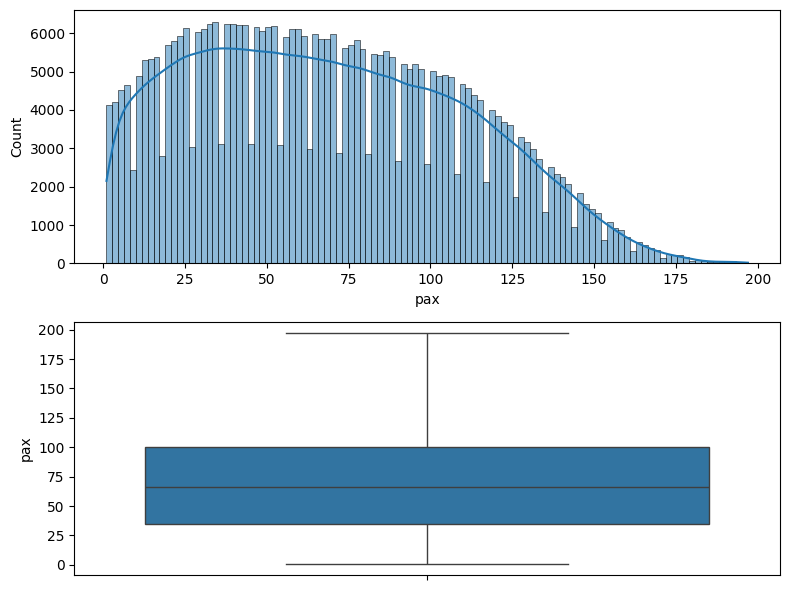

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def remove_outliers(data, col):
    """删除指定列中的异常值"""
    Q1 = data[col].quantile(0.25)  # 第1四分位数
    Q3 = data[col].quantile(0.75)  # 第3四分位数
    IQR = Q3 - Q1  # 四分位距
    lower_bound = Q1 - 1.5 * IQR  # 下限
    upper_bound = Q3 + 1.5 * IQR  # 上限
    
    # 筛选出范围内的数据
    filtered_data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return filtered_data

def plot(data, col):
    """绘制指定列的分布图和箱型图"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
    sns.histplot(data[col], kde=True, ax=ax1)  # 替换 distplot 为 histplot
    sns.boxplot(data[col], ax=ax2)
    plt.tight_layout()
    plt.show()

# 示例数据框
# 假设 df 是你的数据框
# 删除 pax 列中的异常值
filtered_df = remove_outliers(df, 'pax')

# 绘制过滤后的数据分布图和箱型图
plot(filtered_df, 'pax')


## 处理aircraft

In [21]:
# 查看 'cap' 列中每个元素的数据类型
print(df['aircraft'].apply(type).value_counts())

aircraft
<class 'str'>      377108
<class 'float'>         6
Name: count, dtype: int64


In [22]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['aircraft'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['aircraft'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

377114
缺失值的行数: 6
为0的行数: 0


当前aircraft只有6行缺失，我觉得直接删掉这几行即可

In [23]:
# 将 cap 列转换为 Pandas 的 Int64 类型，这种类型支持 NaN 值
# 将 'aircraft' 列转换为字符串类型
# 用 'Unknown' 填充 NaN 值
# df['aircraft'] = df['aircraft'].fillna('Unknown')
# df['aircraft'] = df['aircraft'].astype(str)

In [24]:
# 删除 'aircraft' 列中值为空的行
df = df.dropna(subset=['aircraft'])

In [25]:
# 查看 'cap' 列中每个元素的数据类型
print(df['aircraft'].apply(type).value_counts())

aircraft
<class 'str'>    377108
Name: count, dtype: int64


## 处理cap

In [26]:
# 查看 'cap' 列中每个元素的数据类型
print(df['cap'].apply(type).value_counts())

cap
<class 'int'>    377108
Name: count, dtype: int64


In [27]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['cap'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['cap'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")



377108
缺失值的行数: 0
为0的行数: 124229


cap中有很多行为0，但是我已知了aircraft，理论上来说通过aircraft就知道cap是多少

In [28]:
import pandas as pd
from collections import Counter

# 统计每个 aircraft 对应的 cap 值
aircraft_cap_stats = df[df['cap'] > 0].groupby('aircraft')['cap'].apply(list).to_dict()

# 找到每个 aircraft 的 cap 众数
aircraft_cap_mode = {k: Counter(v).most_common(1)[0][0] for k, v in aircraft_cap_stats.items()}

# 使用众数补充 cap 为 0 的行
df['cap'] = df.apply(lambda row: aircraft_cap_mode[row['aircraft']] if row['cap'] == 0 else row['cap'], axis=1)

# 输出结果
print("各个 aircraft 对应的 cap 众数:")
print(aircraft_cap_mode)
print("\n填充后的 DataFrame:")
print(df)


各个 aircraft 对应的 cap 众数:
{'190': 98, '319': 122, '320': 158, '321': 189, '330': 274, '350': 288, '737': 176, '738': 172, '787': 266, '789': 297, 'ARJ': 90, 'CRJ': 89, 'ERJ': 111}

填充后的 DataFrame:
                          segment        flt_no bd_type  cap aircraft  leg_no  \
15      tKjndGSl9NQ=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体  122      319       3   
16      KETr2NAmAHE=-5t+HPO9Mu/w=  P6p42wyZFEI=      窄体  132      319       2   
17      tKjndGSl9NQ=-KETr2NAmAHE=  P6p42wyZFEI=      窄体  132      319       1   
18      5t+HPO9Mu/w=-tKjndGSl9NQ=  fu7RYrFYvDk=      窄体  122      319       3   
19      KETr2NAmAHE=-tKjndGSl9NQ=  fu7RYrFYvDk=      窄体  132      319       2   
...                           ...           ...     ...  ...      ...     ...   
978441  Eg2bemFsI9I=-KfwFeosCXek=  Rrp6N0B4h44=      窄体  128      319       2   
978442  /M8gHzjxpNU=-Eg2bemFsI9I=  Rrp6N0B4h44=      窄体  128      319       1   
978443  KfwFeosCXek=-/M8gHzjxpNU=  gUgCemIGoZ0=      窄体  122      319       

In [29]:
# 查看 'cap' 列中每个元素的数据类型
print(df['cap'].apply(type).value_counts())
print(df['aircraft'].apply(type).value_counts())

cap
<class 'int'>    377108
Name: count, dtype: int64
aircraft
<class 'str'>    377108
Name: count, dtype: int64


## 处理duration（待做）

In [30]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['duration'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['duration'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

377108
缺失值的行数: 0
为0的行数: 124230


In [31]:
# 统计每个 segment 对应的 duration 均值（排除 0）
segment_duration_mean = df[df['duration'] > 0].groupby('segment')['duration'].mean().to_dict()

# 计算全体 duration 的均值（排除 0）
global_duration_mean = df[df['duration'] > 0]['duration'].mean()

# 使用均值补充 duration 为 0 的行，优先使用 segment 的均值，不存在时使用全体均值
df['duration'] = df.apply(
    lambda row: segment_duration_mean.get(row['segment'], global_duration_mean) if row['duration'] == 0 else row['duration'],
    axis=1
)

# 输出结果
print("各个 segment 对应的 duration 均值:")
print(segment_duration_mean)
print(f"\n全体 duration 的均值: {global_duration_mean:.2f}")
print("\n填充后的 DataFrame:")
print(df)

各个 segment 对应的 duration 均值:
{'+3eoTOkHfoU=-UO2RniR7lJ8=': 0.6980000000000001, '+O1iBQtlFGU=-0Koyk9pJc0s=': 1.1966666666666665, '+O1iBQtlFGU=-DInJHXgQayE=': 1.74, '+O1iBQtlFGU=-KETr2NAmAHE=': 2.5949999999999998, '+O1iBQtlFGU=-KFsTKxkC/6g=': 1.7333333333333334, '+O1iBQtlFGU=-Qe7TEMbQt6o=': 2.0466666666666664, '+O1iBQtlFGU=-QyEgIt0M8Sg=': 1.6933333333333334, '+O1iBQtlFGU=-iX2Pe2pxiqQ=': 1.135, '+O1iBQtlFGU=-lI1bSVMW3Tg=': 1.09, '+O1iBQtlFGU=-mljW2xeLSiI=': 0.8302222222222222, '+O1iBQtlFGU=-yypkiQCX5lk=': 1.2662285714285715, '+S5aV4Y0s8w=-/M8gHzjxpNU=': 1.5265555555555554, '+S5aV4Y0s8w=-KETr2NAmAHE=': 2.06, '+S5aV4Y0s8w=-So/c8CkA/Xs=': 2.673243243243243, '+S5aV4Y0s8w=-Szk6NJM5C9Y=': 0.91, '+S5aV4Y0s8w=-hwin1ipuzwk=': 1.6196153846153847, '+S5aV4Y0s8w=-wSF4qXvI044=': 1.6026966292134832, '+S5aV4Y0s8w=-xIqe+QQIQXQ=': 3.401578947368421, '+S5aV4Y0s8w=-zwVGiYamVc0=': 2.289230769230769, '+cjxQ01BFmw=-iX2Pe2pxiqQ=': 0.6477777777777778, '/M8gHzjxpNU=-+S5aV4Y0s8w=': 1.2406741573033708, '/M8gHzjxpNU=-

In [32]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['duration'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['duration'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

377108
缺失值的行数: 0
为0的行数: 0


In [33]:
# 删除原始的 'segment' 字段
df = df.drop(columns=['segment'])

## 处理tkt_rev

有一些异常行的tkt_rev为0，pax却不为0

In [34]:
# 统计 'unit_price' 列中为 0 的行数
zero_count = (df['tkt_rev'] == 0).sum()

# 统计 'unit_price' 列中为 NaN 的行数
nan_count = df['tkt_rev'].isna().sum()

# 输出结果
print(f"tkt_rev 列中为 0 的行数: {zero_count}")
print(f"tkt_rev 列中为 NaN 的行数: {nan_count}")

tkt_rev 列中为 0 的行数: 224
tkt_rev 列中为 NaN 的行数: 0


In [35]:
df = df[df['tkt_rev'] != 0]

# 计算单价 'unit_price'，即 tkt_rev 除以 pax
df['unit_price'] = df['tkt_rev'] / df['pax']

# 删除 'tkt_rev' 列
df = df.drop(columns=['tkt_rev'])

In [36]:
# 输出 'unit_price' 列中值为 0 的所有行
zero_rows = df[df['unit_price'] == 0]

# 查看结果
print(zero_rows)


Empty DataFrame
Columns: [flt_no, bd_type, cap, aircraft, leg_no, duration, pax, a, b, c, from, to, year, month, day, weekday, holiday, hour, minute, second, unit_price]
Index: []

[0 rows x 21 columns]


## 保存文件

In [37]:
# 保存处理后的数据到新的CSV文件
df.to_csv('../../data-hh/my/202410221653-processed.csv', index=False)